In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import torch
import numpy as np
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data
import util_nn
import reinforcement_learning as rl

In [2]:
# --! define a reward function --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 10.0 * np.eye(action_ndim)

setpoint = [1.0, 0.0]

reward_id = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=1.0, lambda_E=0.05)
reward_ood = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=20.0, lambda_E=0.1)

In [3]:
dt = 1e-2

duffing_exc = ex_duffing.duffing_adapter(ex_duffing.make_duffing('exc', reward_ood, dt=dt))
duffing_nom = ex_duffing.duffing_adapter(ex_duffing.make_duffing('nom', reward_id, dt=dt))

In [4]:
# --! make a base policy --!

base_policy = ex_duffing.make_base_policy(
    duffing_nom.env.alpha, duffing_nom.env.delta,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint)

In [5]:
replay_factory = ex_duffing.replay_factory()

nsample = 384
residual_policy = None
zeta = 0.0
zeta_nom = kind.regimes(0, 0)
zeta_exc = kind.regimes(0, 0)

replay_nom = replay_factory.create(duffing_nom, rl.policies(base_policy, residual_policy), zeta, zeta_nom, nsample, 3*nsample)
replay_exc = replay_factory.create(duffing_exc, rl.policies(base_policy, residual_policy), zeta, zeta_exc, nsample, 3*nsample)

nominal region sample number: 122
torch.Size([1, 122, 4])
excursion region sample number: 528
torch.Size([1, 528, 4])
fore samples number: 32
back samples number: 64
window samples number: 96
torch.Size([1, 626, 4])
tensor(0.5507)


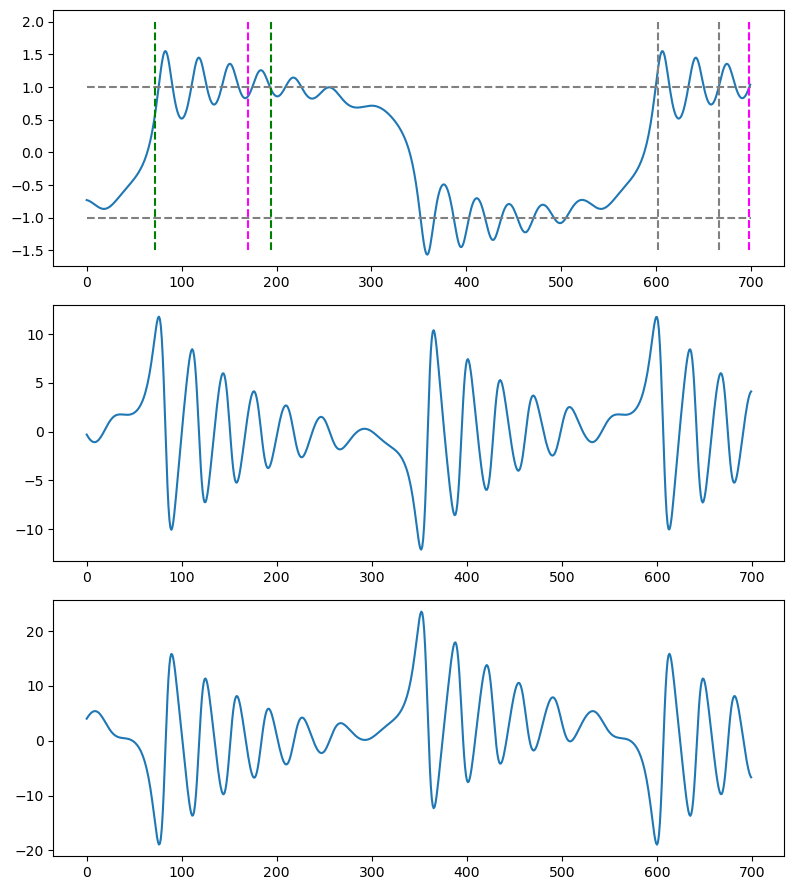

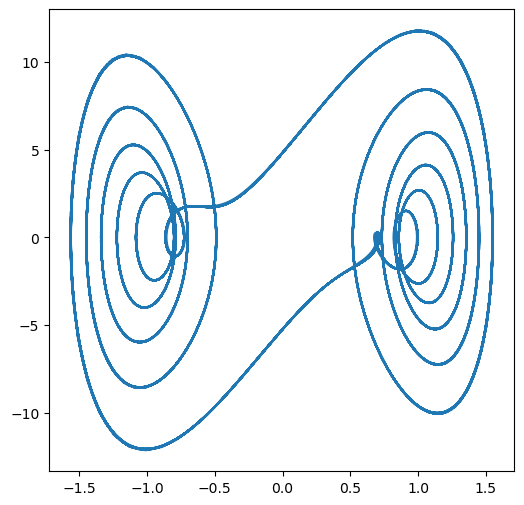

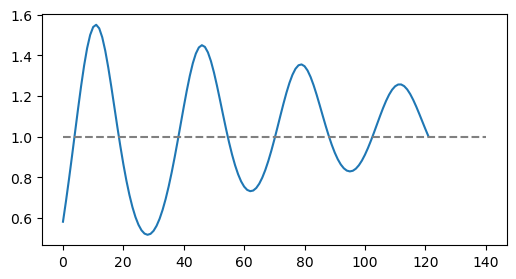

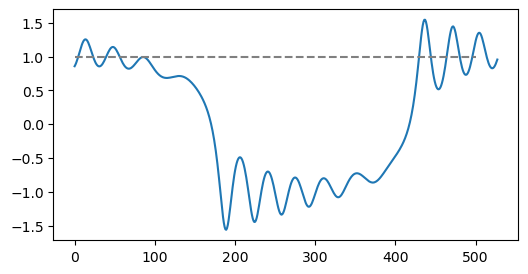

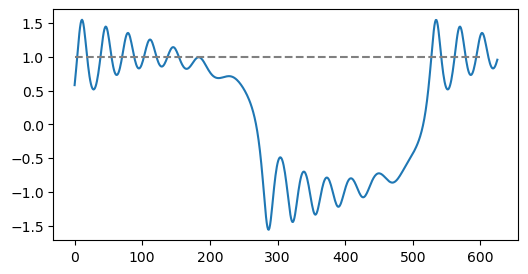

In [6]:
# --! plot results --!

back_exc, _, _, _ = map(torch.cat, zip(*replay_exc.buffer))
state_exc = back_exc[:, [-1]]

traj_start = 700

start_nom = 72
end_nom = 194
size_nom = end_nom - start_nom
print(f'nominal region sample number: {size_nom}')

s_nom = torch.transpose(state_exc, 0, 1)
s_nom = s_nom[[0], -traj_start+start_nom:-traj_start+end_nom, :]
print(s_nom.shape)

start_exc = 170
end_exc = 698
size_exc = end_exc - start_exc
print(f'excursion region sample number: {size_exc}')

s_exc = torch.transpose(state_exc, 0, 1)
s_exc = s_exc[[0], -traj_start+start_exc:-traj_start+end_exc, :]
print(s_exc.shape)

window_fore = 32
window_back = 2 * window_fore
print(f'fore samples number: {window_fore}')
print(f'back samples number: {window_back}')
window_nsample = window_back + window_fore
print(f'window samples number: {window_nsample}')
window_start = 602
window_mid = window_start + window_back
window_end = window_start + window_nsample

s_all = torch.transpose(state_exc, 0, 1)
s_all = s_all[[0], -traj_start+start_nom:-traj_start+end_exc, :]
print(s_all.shape)

s = s_nom[[0], :, :1]
sp = [1.0]
sp = torch.unsqueeze(torch.unsqueeze(torch.tensor(sp), 0), 0)
s = s - sp
sn = torch.max(torch.linalg.norm(s, dim=-1, keepdim=True), dim=1, keepdim=True)[0]
print(sn.max())

with torch.no_grad():
    plt.figure(figsize=(8,9))

    plt.subplot(3,1,1)
    plt.plot(state_exc[-traj_start:, 0, 0])
    plt.plot([window_start,window_start],[-1.5,2], linestyle='dashed', color='gray')
    plt.plot([window_end,window_end],[-1.5,2], linestyle='dashed', color='gray')
    plt.plot([window_mid,window_mid],[-1.5,2], linestyle='dashed', color='gray')
    plt.plot([0, traj_start],[1,1], linestyle='dashed', color='gray')
    plt.plot([0, traj_start],[-1,-1], linestyle='dashed', color='gray')
    plt.plot([start_nom,start_nom],[-1.5,2], linestyle='dashed', color='green')
    plt.plot([end_nom,end_nom],[-1.5,2], linestyle='dashed', color='green')
    plt.plot([start_exc,start_exc],[-1.5,2], linestyle='dashed', color='magenta')
    plt.plot([end_exc,end_exc],[-1.5,2], linestyle='dashed', color='magenta')

    plt.subplot(3,1,2)
    plt.plot(state_exc[-traj_start:, 0, 1])

    plt.subplot(3,1,3)
    plt.plot(state_exc[-traj_start:, 0, 2])

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,6))
    plt.plot(state_exc[:, 0, 0], state_exc[:, 0, 1])
    plt.show()

    plt.figure(figsize=(6,3))
    plt.plot(s_nom[0, :, 0])
    plt.plot([0, 140],[1,1], linestyle='dashed', color='gray')
    plt.show()

    plt.figure(figsize=(6,3))
    plt.plot(s_exc[0, :, 0])
    plt.plot([0, 500],[1,1], linestyle='dashed', color='gray')
    plt.show()

    plt.figure(figsize=(6,3))
    plt.plot(s_all[0, :, 0])
    plt.plot([0, 600],[1,1], linestyle='dashed', color='gray')
    plt.show()


In [7]:
datasaved = False

if datasaved:

    s_ext1_nom = s_nom.clone()
    s_ext2_nom = s_nom.clone()
    s_ext3_nom = s_nom.clone()
    s_ext4_nom = s_nom.clone()
    s_ext_nom = torch.cat([s_nom, s_ext1_nom, s_ext2_nom, s_ext3_nom, s_ext4_nom], dim=0)
    print(f'nominal data saved with shape {s_ext_nom.shape}')
    print(f'excursion data saved with shape {s_exc.shape}')

    print(f'test data saved with shape {s_all.shape}')

    util_data.write_datafile('../../data/dreamer/duffing_nom_0', s_nom.numpy())
    util_data.write_datafile('../../data/dreamer/duffing_exc_0', s_exc.numpy())
    util_data.write_datafile('../../data/dreamer/duffing_all_0', s_all.numpy())